<a href="https://colab.research.google.com/github/mircomarahrens/nconpp/blob/py-dev/qmbs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# high-level interfaces for highly-optimized low-level code
import numpy as np              # arrays and algorithms
import matplotlib.pyplot as plt # visualization

# Introduction

Consider a chain of spins. The chain shall have a length of $L$ and the spins a quantum number $s$. The dimension of the Hilbert space on each site is $d=(2s+1)$. We call this dimension the local dimension. On this scaffold lives an overall hamiltonian $H$ with $H=\sum_{i=1}^{L}{h_i}$. Hamiltonians of this kinds are called local hamiltonians with local acting terms $h_i$. $i$ is a node index corresponding to the set $i\in\{1,\cdots,L\}$. \newline
The local acting terms shall be of the form $h_i=a_i+b_{i,i+1}+c_{i,i+2}$, where $a_i$ is operating purely local, $b_{i,i+1}$ interacts with nearest and $c_{i,i+2}$ with next-nearest neighbor. The Hilbert space of such hamiltonians are $\mathscr{H}=\bigotimes_L{\mathbb{C}^d}$ with an exponentially growing total dimension of $d^L$.

# Prerequisites

Our chain here shall consists of $L=8$ sites and the spin quantum number should correspond to $s=\frac{1}{2}$.

In [ ]:
L = 8                            # number of sites
s = 1/2                          # spin
d = int(2*s+1)                   # local dimension
H_dim = d**L                     # global dimension

We specify the action terms in our Hamiltonian by

- on-site $a_i$
- nearest neighbor $b_{i,i+1}$
- next-nearest neighbot $c_{i,i+2} = c_i I_{i+1} c_{i+2}$

$a, b$ and $c$ are any operators from the set of Pauli operators $\{X,Y,Z\}$. $I$ is the identity matrix. They are given by

$$
I = \begin{pmatrix}1&0\\0&1\end{pmatrix}, X = \begin{pmatrix}0&1\\1&0\end{pmatrix}, Y = \begin{pmatrix}0&-i\\i&0\end{pmatrix}, Z = \begin{pmatrix}1&0\\0&-1\end{pmatrix}.
$$

In [ ]:
I = np.eye(d)                    # identity matrix
X = np.array([[0.,1.],[1.,0.]])  # pauli $\sigma_x$ matrix
Y = np.array([[0.,-1j],[1j,0.]]) # pauli $\sigma_y$ matrix
Z = np.array([[1.,0.],[0.,-1.]]) # pauli $\sigma_z$ matrix

# Matrix Product States

Quantum states are obeying the relation

$$
|\psi\rangle = \sum_{\sigma_1\cdots\sigma_L}{m^{\sigma_1\cdots\sigma_L}|\sigma_1\cdots\sigma_L\rangle}.
$$

Here $m^{\sigma_1\cdots\sigma_L}$ are coefficients, which obeys the Euclidean norm $\lVert m^{\sigma_1\cdots\sigma_L} \rVert_2 = 1$. This relation can be reexpressed by local site terms. The final decomposition are called Matrix Product States (MPS). Those are given by

$$
\begin{align}
|\psi\rangle &= \sum_{\sigma_1\cdots\sigma_L}{m^{\sigma_1\cdots\sigma_L}|\sigma_1\cdots\sigma_L\rangle} \\
&= \sum_{\sigma_1\cdots\sigma_L}\prod_{i=1}^L M_i^{\sigma_i}|\sigma_1\cdots\sigma_L\rangle.
\end{align}
$$

In [ ]:
# register: random mps for spin chains d=2
mps = np.reshape(np.array((np.random.rand(L), np.random.rand(L))), (L, int(d)))

# Matrix decomposition

Local hamiltonians can be decomposed into products of matrices. The representation of the matrices are called Matrix Product Operators (MPO). They are taking the form

$$
H = \sum_i{h_i} = \sum_{\sigma_1^\prime\cdots\sigma_L^\prime,\\\sigma_1\cdots\sigma_L} \prod_{i=1}^L{W_i^{\sigma_i^\prime,\sigma_i}}|\sigma_1^\prime\cdots\sigma_L^\prime\rangle\langle\sigma_1\cdots\sigma_L|.
$$

The W-matrices are lower or upper triangular matrices. The upper-triangular form are given by kinds of

$$
W_i^{\sigma_i^\prime,\sigma_i^{\,}} =
\begin{pmatrix}
    I & C & D \\
    0 & A & B \\
    0 & 0 & I
\end{pmatrix}_{(i)}.
$$

The subform of the blocks $A,B,C$ and $D$ are given by different ranges of interactions: $D$ are purely on-site operators, whereas $C$ is a $1 \times N_i$ row-, $B$ a $N_{i-1} \times 1$ column vector of operators. $A$ is a $N_{i-1} \times N_i$-matrix of operators. Details can be found here <https://arxiv.org/pdf/1407.1832.pdf>.



# Finite State Machine

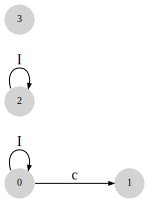

In [42]:
from graphviz import Digraph

fsm = Digraph(
    graph_attr={
        'rankdir':'LR',
        'splines':'true',
        'color':'transparent',
        'ranksep':'1'
    },
    node_attr={
        'style':'filled',
        'color':'white',
        'shape':'circle',
        'height':'0.1',
        'fillcolor':'lightgray',
        'fontsize':'10'
    },
    edge_attr={
        'arrowsize':'0.5'
    }
)

fsm.node(name='0', label='0')
fsm.node(name='1', label='1')
fsm.node(name='2', label='2')
fsm.node(name='3', label='3')

fsm.edge('0','0', label='I')
fsm.edge('0','1', label='c')
fsm.edge('2','2', label='I')

fsm

# Matrix product diagram

We mimic the system here to have periodic boundary conditions by forming a ring, i.e. the almost right-hand side is connected by the almost left-hand side. This makes it easier to handle the matrix product algorithm.

In [ ]:
from graphviz import Digraph

sites = 8
transitions = sites + 1
channels = 3

# graph
graph = Digraph(
        graph_attr={
            'rankdir':'LR',
            'splines':'false',
            'color':'transparent',
            'ranksep':'1'
        },
        node_attr={
            'style':'filled',
            'color':'white',
            'shape':'circle',
            'height':'0.1',
            'fillcolor':'lightgray',
            'fontsize':'10'
        },
        edge_attr={
            'arrowsize':'0.5'
        }
    )

# nodes
prefix = {0: 'a', 1: 'b', 2: 'c'}
with graph.subgraph(name='cluster_I') as child:
    for i in range(transitions):
        child.node(name='I' + str(i), label='0')

for j in range(channels):
    with graph.subgraph(name='cluster_' + prefix[j]) as child:
        for i in range(transitions):
            child.node(name=prefix[j] + str(i), label=str(j+1))

with graph.subgraph(name='cluster_F') as child:
    for i in range(transitions):
        child.node(name='F' + str(i), label=str(channels + 1))

# edges
graph.edges([('I' + str(i),'I' + str(i+1)) for i in range(transitions-1)])
for i in range(transitions):
    graph.edge('I' + str(i), 'a' + str(i), style='invis')
    graph.edge('a' + str(i), 'b' + str(i), style='invis')
    graph.edge('b' + str(i), 'c' + str(i), style='invis')
    graph.edge('c' + str(i), 'F' + str(i), style='invis')
graph.edges([('F' + str(i),'F' + str(i+1)) for i in range(transitions-1)])

#graph.edges()
for i in range(transitions-1):
    # graph.edge('I' + str(i), 'I' + str(i+1))
    graph.edge('I' + str(i), 'a' + str(i+1))
    graph.edge('I' + str(i), 'b' + str(i+1), style='invis')
    graph.edge('I' + str(i), 'c' + str(i+1))
    graph.edge('I' + str(i), 'F' + str(i+1))
    graph.edge('a' + str(i), 'I' + str(i+1), style='invis')
    graph.edge('a' + str(i), 'a' + str(i+1), style='invis')
    graph.edge('a' + str(i), 'b' + str(i+1))
    graph.edge('a' + str(i), 'c' + str(i+1), style='invis')
    graph.edge('a' + str(i), 'F' + str(i+1), style='invis')
    graph.edge('b' + str(i), 'I' + str(i+1), style='invis')
    graph.edge('b' + str(i), 'a' + str(i+1), style='invis')
    graph.edge('b' + str(i), 'b' + str(i+1), style='invis')
    graph.edge('b' + str(i), 'c' + str(i+1), style='invis')
    graph.edge('b' + str(i), 'F' + str(i+1))
    graph.edge('c' + str(i), 'I' + str(i+1), style='invis')
    graph.edge('c' + str(i), 'a' + str(i+1), style='invis')
    graph.edge('c' + str(i), 'b' + str(i+1), style='invis')
    graph.edge('c' + str(i), 'c' + str(i+1), style='invis')
    graph.edge('c' + str(i), 'F' + str(i+1))
    graph.edge('F' + str(i), 'I' + str(i+1), style='invis')
    graph.edge('F' + str(i), 'a' + str(i+1), style='invis')
    graph.edge('F' + str(i), 'b' + str(i+1), style='invis')
    graph.edge('F' + str(i), 'c' + str(i+1), style='invis')
    # graph.edge('F' + str(i), 'F' + str(i+1))

The matrix product diagram for the system here is

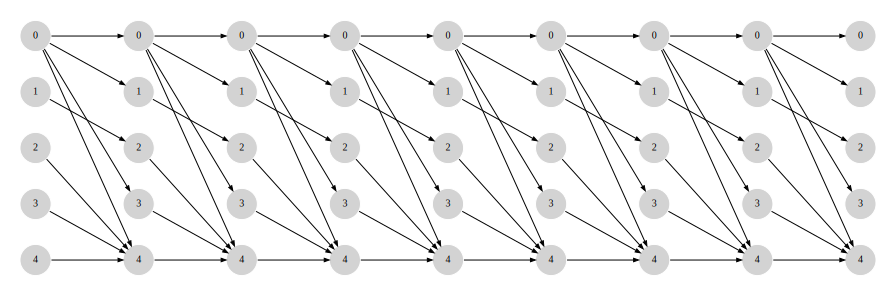

In [ ]:
graph

The matrix product operators are $5 \times 5$ matrices which are taking the form

$$
W_i^{\sigma_i^\prime,\sigma_i^{\,}} =
\begin{pmatrix}
I_{00} & c_{01} & c_{02} & c_{03} & d_{44} \\
0      & a_{11} & a_{12} & a_{13} & b_{14} \\
0      & 0      & a_{22} & a_{23} & b_{24} \\
0      & 0      & 0      & a_{33} & b_{34} \\
0      & 0      & 0      & 0      & I_{44}
\end{pmatrix}_{(i)}.
$$

The entries of this matrices corresponding to the edges of the matrix product diagram above, whereby the indices are given by the nodes, though

$$
\begin{align}
C &=
\begin{pmatrix}
c_{01} & c_{02} & c_{03}
\end{pmatrix}
=
\begin{pmatrix}
c & 0 & b
\end{pmatrix}
\\
D &= d_{44} = a \\
A &=
\begin{pmatrix}
a_{11} & a_{12} & a_{13} \\
0      & a_{22} & a_{23} \\
0      & 0      & a_{33} \\
\end{pmatrix}
=
\begin{pmatrix}
0 & I & 0 \\
0 & 0 & 0 \\
0 & 0 & 0 \\
\end{pmatrix} \\
B &=
\begin{pmatrix}
b_{14} \\
b_{24} \\
b_{34}
\end{pmatrix}
=
\begin{pmatrix}
0 \\
c \\
b
\end{pmatrix}
\end{align},
$$

so that the final form is

$$
W_i^{\sigma_i^\prime,\sigma_i^{\,}} =
\begin{pmatrix}
I & c & 0 & b & a \\
0 & 0 & I & 0 & 0 \\
0 & 0 & 0 & 0 & c \\
0 & 0 & 0 & 0 & b \\
0 & 0 & 0 & 0 & I
\end{pmatrix}_{(i)}.
$$

In [35]:
from graphviz import Digraph

fsm = Digraph(
    graph_attr={
        'rankdir':'LR',
        'splines':'true',
        'color':'transparent',
        'ranksep':'1'
    },
    node_attr={
        'style':'filled',
        'color':'white',
        'shape':'circle',
        'height':'0.1',
        'fillcolor':'lightgray',
        'fontsize':'10'
    },
    edge_attr={
        'arrowsize':'0.5'
    }
)

fsm.node(name='0', label='0')
fsm.node(name='1', label='1')
fsm.node(name='2', label='2')
fsm.node(name='3', label='3')
fsm.node(name='4', label='4')

fsm.edge('0','0', label='I')
fsm.edge('0','1', label='c')
fsm.edge('0','3', label='b')
fsm.edge('0','4', label='d')
fsm.edge('1','2', label='I')
fsm.edge('2','4', label='c')
fsm.edge('3','4', label='b')
fsm.edge('4','4', label='I')

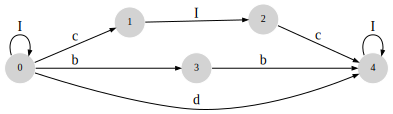

In [36]:
fsm